In [1]:
import anndata
import pandas as pd
import scimap as sm
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import pandas as pd
import matplotlib.colors as mcolors
warnings.simplefilter(action='ignore', category=FutureWarning)

Running SCIMAP  2.1.3


/Users/chiaraschiller/miniconda3/envs/scimap_local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



This script reproduces Supplementary Figure 9 of Schiller et al 2025, looking at correlation between the CCR and the cell percentage in manually annotated regions and the correlation between NEP results across different neighborhood definitions.

In [2]:
path_to_csv = './../../../../../../MI_heart_paper/data/cell_table_final.csv'
obs = pd.read_csv(path_to_csv)
output_path = './../../../../Comparison/20250218_results_MI/MI_COZI_normalized_knn5.csv'
NEP_method = "COZI"
label = 'COZI_knn5'

In [3]:
# exclude the specified cell types in obs
ignore_cell_types = ['exclude']
obs = obs[~obs['final_cell_type'].isin(ignore_cell_types)]

In [4]:
#create anndata object
# add marker files to it, as SpatialLDA needs them
obs['D'] = np.random.randint(1, 101, size=len(obs))
obs['E'] = np.random.randint(1, 101, size=len(obs))

# Ensure obs has a string-based index
obs.index = obs.index.astype(str)  # Convert index to string


# Load dataframe into anndata object
# the data matrix 
X = obs[['D', 'E']]
X = X.values
adata = anndata.AnnData(X)
adata.obs = obs
adata

AnnData object with n_obs × n_vars = 563180 × 2
    obs: 'fov', 'label', 'cell_size', 'X_centroid', 'Y_centroid', 'Eccentricity', 'Solidity', 'Extent', 'Orientation', 'cell_meta_cluster', 'timepoint', 'region', 'region_name', 'refined_cell_type', 'final_cell_type', 'endocardial_annotation', 'exclude_annotation', 'artefact', 'distance_from_lumen', 'lumen_bin', 'size_filter', 'D', 'E'

## COZI NEP analysis across different nbh definitions

In [5]:
NEP_method = 'COZI'

In [6]:
# Define all neighborhood definitions you want to test
nbc_defs = [
    {"method": "radius", "radius": 50, "label": "radius50"},
    {"method": "radius", "radius": 100, "label": "radius100"},
    {"method": "radius", "radius": 150, "label": "radius150"},
    {"method": "knn", "knn": 5, "label": "knn5"},
    {"method": "knn", "knn": 10, "label": "knn10"},
    {"method": "knn", "knn": 15, "label": "knn15"},
    {"method": "delaunay", "label": "delaunay"},
]

results = {}

for nbc in nbc_defs:
    # Start from base params
    spatial_params = {
        'adata': adata,
        'x_coordinate': 'X_centroid',
        'y_coordinate': 'Y_centroid',
        'phenotype': 'final_cell_type',
        'method': nbc["method"],
        'permutation': 300,
        'imageid': 'fov',
        'min_celltype_count': 20,
        'subset': None,
        'pval_method': 'zscore',
        'verbose': True,
        'label': nbc["label"]
    }

    # Add radius or knn only if needed
    if "radius" in nbc:
        spatial_params["radius"] = nbc["radius"]
    if "knn" in nbc:
        spatial_params["knn"] = nbc["knn"]

    # Add conditional normalization depending on NEP_method
    if NEP_method == 'SEA':
        spatial_params['normalization'] = 'total'
    elif NEP_method == 'COZI':
        spatial_params['normalization'] = 'conditional'

    print(f"Running {nbc['label']} ...")
    spatial = sm.tl.spatial_interaction(**spatial_params)

    # Save results in dictionary under its label
    results[nbc["label"]] = spatial

Running radius50 ...
Processing Image: ['24h_86']
Retaining 11 phenotypes with ≥ 20 cells
Identifying neighbours within 50 pixels of every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['24h_83']
Retaining 11 phenotypes with ≥ 20 cells
Identifying neighbours within 50 pixels of every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Control_13']
Retaining 10 phenotypes with ≥ 20 cells
Identifying neighbours within 50 pixels of every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Control_12']
Retaining 10 phenotypes with ≥ 20 cells
Identifying neighbours within 50 pixels of every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['4h_97']
Retaining 11 phenotypes with ≥ 20 cells
Identifying neighbours 

/Users/chiaraschiller/miniconda3/envs/scimap_local/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['Control_13']
Retaining 10 phenotypes with ≥ 20 cells
Identifying neighbours within 100 pixels of every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Control_12']
Retaining 10 phenotypes with ≥ 20 cells
Identifying neighbours within 100 pixels of every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['4h_97']
Retaining 11 phenotypes with ≥ 20 cells
Identifying neighbours within 100 pixels of every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['4h_96']
Retaining 11 phenotypes with ≥ 20 cells
Identifying neighbours within 100 pixels of every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['48h_79']
Retaining 11 phenotypes with ≥ 20 cells
Ide

/Users/chiaraschiller/miniconda3/envs/scimap_local/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['48h_79']
Retaining 11 phenotypes with ≥ 20 cells
Identifying neighbours within 150 pixels of every cell
Mapping phenotype to neighbors
Performing 300 permutations


/Users/chiaraschiller/miniconda3/envs/scimap_local/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['48h_76']
Retaining 11 phenotypes with ≥ 20 cells
Identifying neighbours within 150 pixels of every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Control_14']
Retaining 9 phenotypes with ≥ 20 cells
Identifying neighbours within 150 pixels of every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Running knn5 ...
Processing Image: ['24h_86']
Retaining 11 phenotypes with ≥ 20 cells
Identifying the 5 nearest neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['24h_83']
Retaining 11 phenotypes with ≥ 20 cells
Identifying the 5 nearest neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Control_13']
Retaining 10 phenotypes with ≥ 

/Users/chiaraschiller/miniconda3/envs/scimap_local/lib/python3.10/site-packages/seaborn/matrix.py:1124: UserWarning:

``square=True`` ignored in clustermap



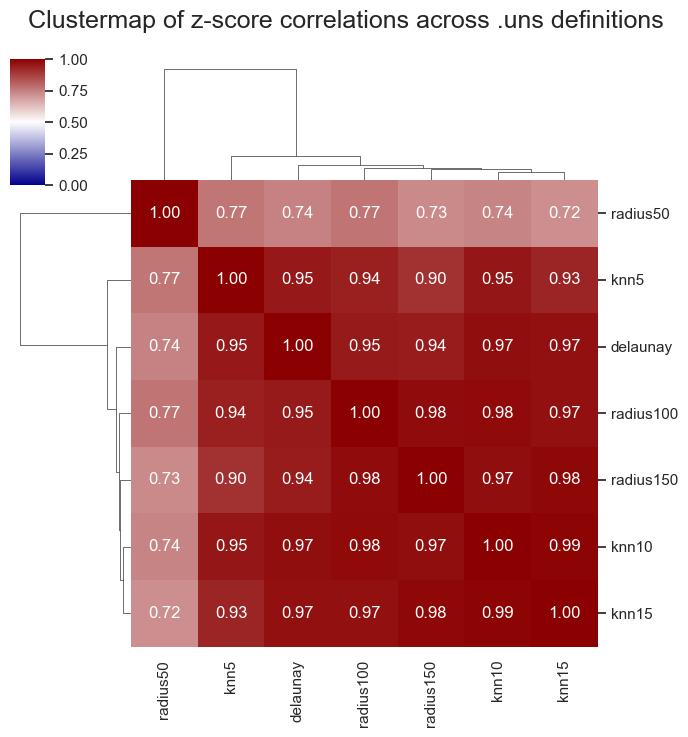

In [7]:
zscore_vectors = {}

for key in adata.uns:
    df = adata.uns[key]
    if not isinstance(df, pd.DataFrame):
        continue

    # Create interaction label
    df["interaction"] = df["phenotype"] + "_" + df["neighbour_phenotype"]
    
    # Identify all z-score columns
    zscore_cols = [col for col in df.columns if col.startswith("zscore_")]
    if len(zscore_cols) == 0:
        continue

    # Melt the dataframe so each z-score entry becomes one row
    melted = df.melt(id_vars="interaction", value_vars=zscore_cols, 
                     var_name="sample", value_name="zscore")
    
    # Create a unique label for each entry (interaction + sample)
    melted["interaction_sample"] = melted["interaction"] + "_" + melted["sample"].str.replace("zscore_", "")

    # Store in dict: key = uns label, value = z-score Series with unique index
    zscore_vectors[key] = melted.set_index("interaction_sample")["zscore"]

# Step 2: Combine into one big DataFrame (outer join on all interaction-sample combinations)
zscore_df = pd.DataFrame(zscore_vectors)

# Step 3: Drop rows with NaN (only keep interaction-samples present in all .uns)
zscore_df_clean = zscore_df.dropna()

# Step 4: Correlation matrix
corr_matrix = zscore_df_clean.corr()

# Step 5: Clustered heatmap
cmap = mcolors.LinearSegmentedColormap.from_list("blue_white_red", ["darkblue", "white", "darkred"])

# Set normalization so that:
# 0   = blue
# 0.5 = white (center point)
# 1   = red
norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=0.5, vmax=1)

# Plot clustered heatmap
sns.clustermap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    norm=norm,
    figsize=(7, 7),
    square=True
)

plt.suptitle("Clustermap of z-score correlations across .uns definitions", y=1.05, fontsize=18)
plt.savefig(
    "./../../../../../Paper_figures/202506_dotplots/nbh_def_correlation_global_finalsub.svg",
    format="svg", dpi=300, bbox_inches="tight"
)
plt.show()


In [ ]:
# save corr_matrix as excel file
corr_matrix.to_excel('./../../../../../data/Source_data/Source_Sup_11a.xlsx')

### CONTINUE TO SAVE HERE

In [14]:
def plot_interaction_correlation(adata, target_interaction, out_prefix):
    """
    Plot clustered heatmap of correlation between z-scores for a given cell-cell interaction
    across different .uns definitions in adata.
    
    Parameters
    ----------
    adata : AnnData
        The annotated data object containing .uns with zscore tables.
    target_interaction : str
        Interaction label, e.g. "Cardiomyocytes_Cardiomyocytes Ankrd1+".
    out_prefix : str
        Prefix for output filename (SVG will be saved).
    """
    
    # Step 1: Extract filtered z-score vectors
    zscore_vectors_filtered = {}
    for key in adata.uns:
        df = adata.uns[key]
        if not isinstance(df, pd.DataFrame):
            continue

        # Create interaction label
        df["interaction"] = df["phenotype"] + "_" + df["neighbour_phenotype"]

        # Filter only for the desired interaction
        df_filtered = df[df["interaction"] == target_interaction]
        if df_filtered.empty:
            continue

        # Identify z-score columns
        zscore_cols = [col for col in df_filtered.columns if col.startswith("zscore_")]
        if len(zscore_cols) == 0:
            continue

        # Melt into long format
        melted = df_filtered.melt(
            id_vars="interaction", 
            value_vars=zscore_cols, 
            var_name="sample", 
            value_name="zscore"
        )

        # Clean sample names
        melted["sample"] = melted["sample"].str.replace("zscore_", "", regex=False)
        melted.set_index("sample", inplace=True)

        # Save vector
        zscore_vectors_filtered[key] = melted["zscore"]

    # Step 2: Combine vectors
    zscore_df_filtered = pd.DataFrame(zscore_vectors_filtered)

    # Step 3: Drop NaNs
    zscore_df_filtered_clean = zscore_df_filtered.dropna()
    if zscore_df_filtered_clean.empty:
        print(f"⚠️ No shared samples found for {target_interaction}. Skipping.")
        return

    # Step 4: Correlation matrix
    corr_matrix_filtered = zscore_df_filtered_clean.corr()

    # Step 5: Define custom colormap
    cmap = mcolors.LinearSegmentedColormap.from_list("blue_white_red", ["darkblue", "white", "darkred"])
    norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=0.5, vmax=1)

    # Step 6: Plot clustered heatmap
    g = sns.clustermap(
        corr_matrix_filtered,
        annot=True,
        fmt=".2f",
        cmap=cmap,
        norm=norm,
        figsize=(7, 7),
        square=True
    )
    target_interaction_clean = target_interaction.replace(" ", "_").replace("/", "_").replace("+", "pos")
    corr_matrix_filtered.to_excel(f'./../../../../../data/Source_data/Source_Sup_11_{target_interaction_clean}.xlsx')
    g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=16, rotation=90)
    g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=16)
    for text in g.ax_heatmap.texts:
        text.set_fontsize(12)

    plt.suptitle(f"Clustermap of z-score correlations for {target_interaction}", y=1.05)
    out_path = f"./../../../../../Paper_figures/202506_dotplots/{out_prefix}.svg"
    plt.savefig(out_path, format="svg", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"✅ Saved: {out_path}")


/Users/chiaraschiller/miniconda3/envs/scimap_local/lib/python3.10/site-packages/seaborn/matrix.py:1124: UserWarning:

``square=True`` ignored in clustermap



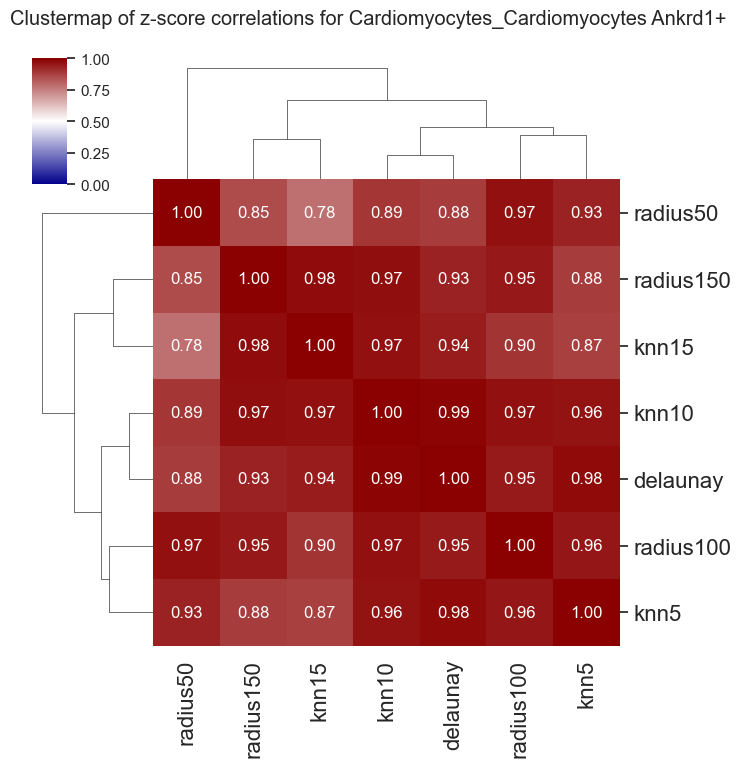

✅ Saved: ./../../../../../Paper_figures/202506_dotplots/nbh_def_correlation_Cardiomyocytes_Cardiomyocytes_Ankrd1pos.svg


/Users/chiaraschiller/miniconda3/envs/scimap_local/lib/python3.10/site-packages/seaborn/matrix.py:1124: UserWarning:

``square=True`` ignored in clustermap



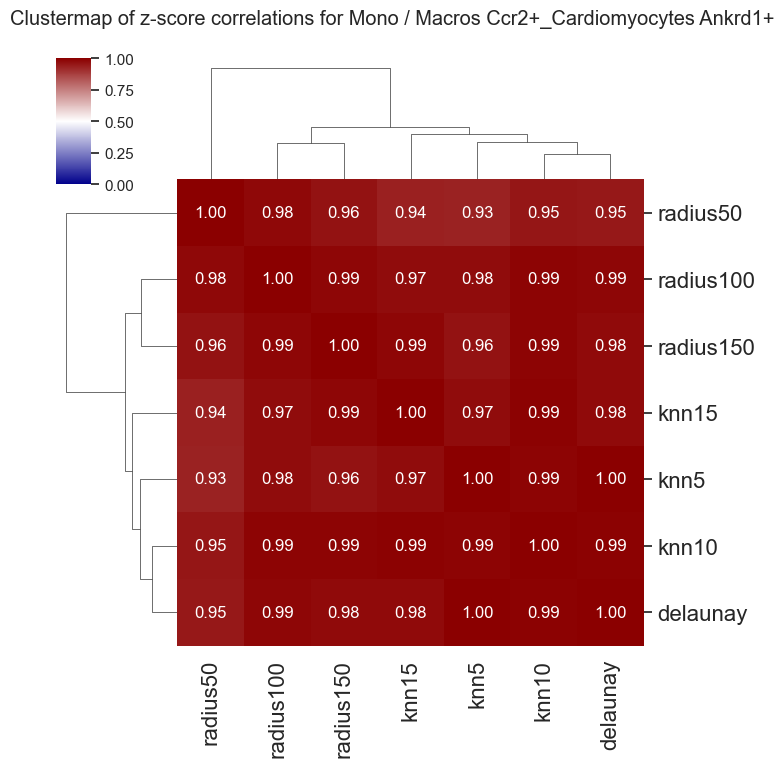

✅ Saved: ./../../../../../Paper_figures/202506_dotplots/nbh_def_correlation_Mono_-_Macros_Ccr2pos_Cardiomyocytes_Ankrd1pos.svg


/Users/chiaraschiller/miniconda3/envs/scimap_local/lib/python3.10/site-packages/seaborn/matrix.py:1124: UserWarning:

``square=True`` ignored in clustermap



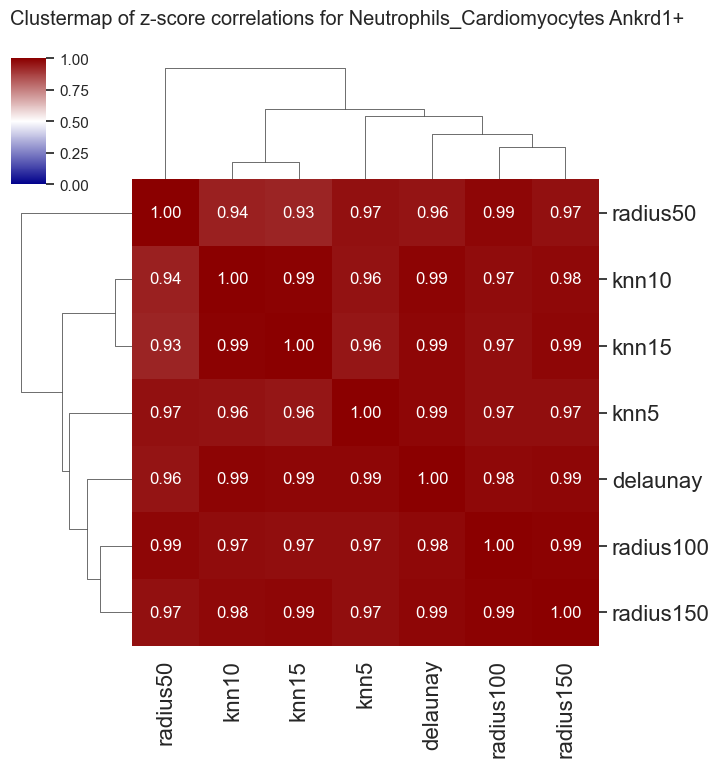

✅ Saved: ./../../../../../Paper_figures/202506_dotplots/nbh_def_correlation_Neutrophils_Cardiomyocytes_Ankrd1pos.svg


/Users/chiaraschiller/miniconda3/envs/scimap_local/lib/python3.10/site-packages/seaborn/matrix.py:1124: UserWarning:

``square=True`` ignored in clustermap



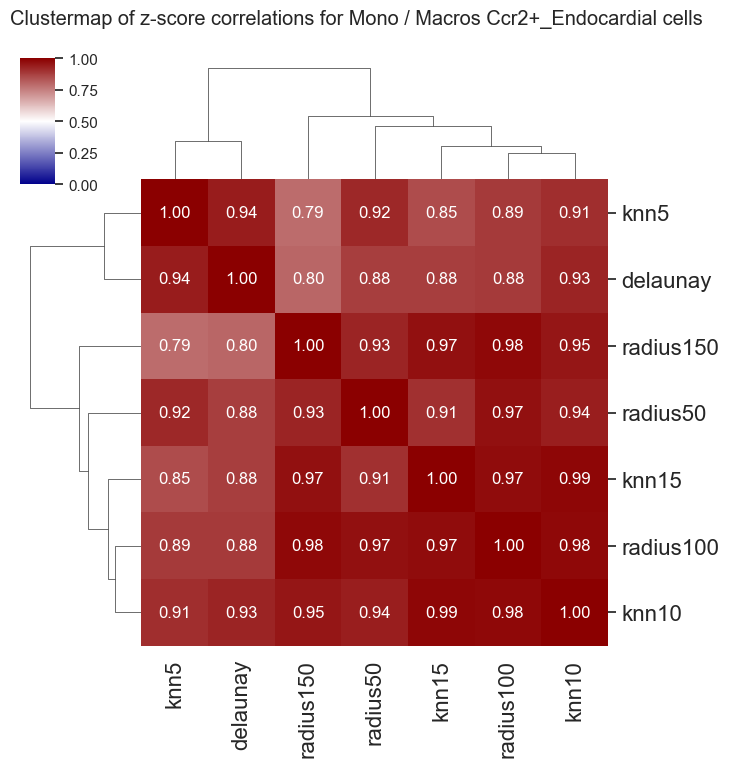

✅ Saved: ./../../../../../Paper_figures/202506_dotplots/nbh_def_correlation_Mono_-_Macros_Ccr2pos_Endocardial_cells.svg


/Users/chiaraschiller/miniconda3/envs/scimap_local/lib/python3.10/site-packages/seaborn/matrix.py:1124: UserWarning:

``square=True`` ignored in clustermap



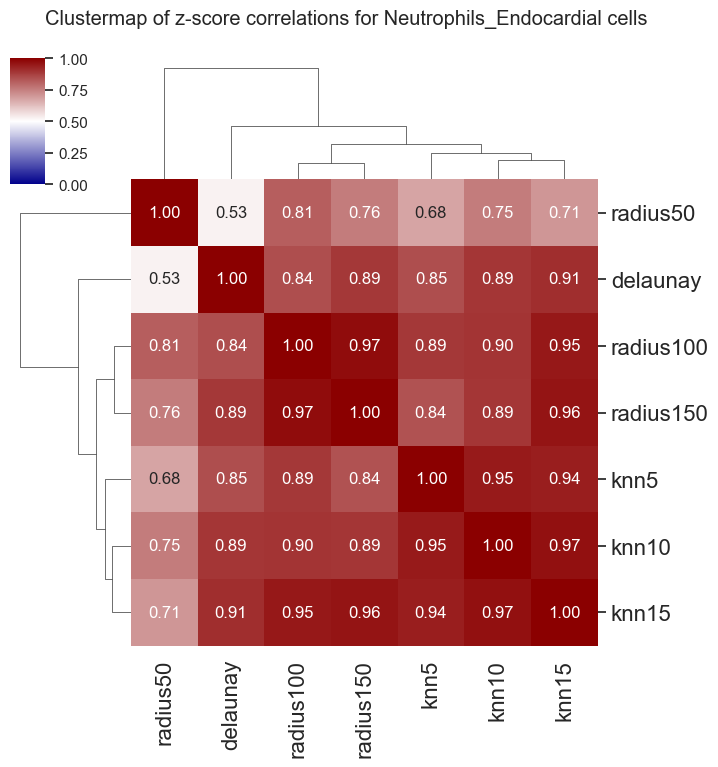

✅ Saved: ./../../../../../Paper_figures/202506_dotplots/nbh_def_correlation_Neutrophils_Endocardial_cells.svg


In [15]:
interactions = [
    "Cardiomyocytes_Cardiomyocytes Ankrd1+",
    "Mono / Macros Ccr2+_Cardiomyocytes Ankrd1+",
    "Neutrophils_Cardiomyocytes Ankrd1+",
    "Mono / Macros Ccr2+_Endocardial cells",
    "Neutrophils_Endocardial cells"
]

for interaction in interactions:
    safe_label = interaction.replace(" ", "_").replace("+", "pos").replace("/", "-")
    plot_interaction_correlation(adata, interaction, f"nbh_def_correlation_{safe_label}")

## CCR and manual annotation correlation

In [16]:
def compute_region_percentages(adata, target_region):
    """
    Compute the percentage of cells of each cell type in the target region(s), per FOV.

    Parameters
    ----------
    adata : AnnData
        The annotated data matrix with `adata.obs` containing 'region_name', 'fov', and 'final_cell_type'.
    target_region : str or list of str
        Region(s) of interest.

    Returns
    -------
    pd.DataFrame
        A dataframe with percentages of cells in the target region(s), grouped by FOV and cell type.
    """
    # Ensure list
    if isinstance(target_region, str):
        target_region = [target_region]

    # Copy obs and add binary flag
    obs_df = adata.obs.copy()
    obs_df["target_region"] = obs_df["region_name"].isin(target_region).astype(int)

    # Group by fov and cell type, compute percentage
    percentage_df = (
        obs_df.groupby(["fov", "final_cell_type"])["target_region"]
        .mean() * 100
    ).reset_index()

    # Rename column with joined region name(s)
    region_label = "_or_".join(target_region)
    percentage_df = percentage_df.rename(columns={"target_region": f"percent_in_{region_label}"})

    return percentage_df

In [17]:
df1 = compute_region_percentages(adata, "endocardial_region")
df2 = compute_region_percentages(adata, ["border_zone", "infarct_core"])

In [18]:
df = results['knn5'].uns['knn5']
df['phenotype'] = df['phenotype'].astype(str)
df['neighbour_phenotype'] = df['neighbour_phenotype'].astype(str)

# Create interaction label
df['interaction'] = df['phenotype'] + "_" + df['neighbour_phenotype']

# Melt the dataframe into long format
df_melted = df.melt(id_vars=['phenotype', 'neighbour_phenotype', 'interaction'], var_name='metric', value_name='value')

# Extract type of metric and condition
df_melted['metric_type'] = df_melted['metric'].str.extract(r'^(zscore|cond_cell_ratio)')
df_melted['condition'] = df_melted['metric'].str.replace(r'^(zscore|cond_cell_ratio)_', '', regex=True)

# Pivot so we get one row per (interaction, condition) with both zscore and cond_cells
df_pivot = df_melted.pivot_table(index=['interaction', 'condition'], 
                                 columns='metric_type', 
                                 values='value').reset_index()

df_pivot['zscore'] = pd.to_numeric(df_pivot['zscore'], errors='coerce').astype(float)
df_pivot['cond_cell_ratio'] = pd.to_numeric(df_pivot['cond_cell_ratio'], errors='coerce').astype(float)


df_pivot

metric_type,interaction,condition,cond_cell_ratio,zscore
0,Cardiomyocytes Ankrd1+_Cardiomyocytes,24h_83,0.144231,-71.250221
1,Cardiomyocytes Ankrd1+_Cardiomyocytes,24h_86,0.428135,-103.115167
2,Cardiomyocytes Ankrd1+_Cardiomyocytes,48h_76,0.093928,-39.743580
3,Cardiomyocytes Ankrd1+_Cardiomyocytes,48h_79,0.085152,-49.077816
4,Cardiomyocytes Ankrd1+_Cardiomyocytes,4h_96,0.569736,-75.166491
...,...,...,...,...
1002,Smooth muscle cells_Smooth muscle cells,4h_96,0.731884,29.820677
1003,Smooth muscle cells_Smooth muscle cells,4h_97,0.751227,41.135113
1004,Smooth muscle cells_Smooth muscle cells,Control_12,0.593567,11.152171
1005,Smooth muscle cells_Smooth muscle cells,Control_13,0.686581,29.613801


In [25]:
def plot_region_interaction_correlation(
        df1,
        df2,
        target_celltype,
        target_interaction,
        region_column="percent_in_endocardial_region",
        xlim=None,
        ylim=None,
        savepath=None):
    """
    Plot correlation between celltype abundance in region and interaction ratio.
    
    Parameters
    ----------
    df1 : pd.DataFrame
        DataFrame with region percentages per fov and cell type.
    df2 : pd.DataFrame
        DataFrame with interaction ratios (df_pivot).
    target_celltype : str
        Cell type to filter in df1.
    target_interaction : str
        Interaction to filter in df2.
    region_column : str, default="percent_in_endocardial_region"
        Column in df1 to correlate.
    xlim : tuple, optional
        Limits for x-axis.
    ylim : tuple, optional
        Limits for y-axis.
    savepath : str, optional
        Path to save the figure (if None, does not save).
    """

    # Filter df1 by celltype
    sub_df1 = df1[df1["final_cell_type"] == target_celltype].copy()

    # Filter df2 by interaction
    sub_df2 = df2[df2["interaction"] == target_interaction].copy()

    # Merge
    merged = sub_df1.merge(sub_df2, left_on="fov", right_on="condition")

    # Clean
    merged_clean = merged[
        merged[region_column].notna() & merged["cond_cell_ratio"].notna()
        & ~merged[region_column].isin([float("inf"), -float("inf")]) &
        ~merged["cond_cell_ratio"].isin([float("inf"), -float("inf")])].copy()

    if merged_clean.empty:
        raise ValueError("No valid data after filtering for correlation.")

    # Correlation
    r, p_value = pearsonr(merged_clean[region_column],
                          merged_clean["cond_cell_ratio"])

    # Plot
    plt.figure(figsize=(4, 4))
    plt.scatter(merged_clean[region_column],
                merged_clean["cond_cell_ratio"],
                alpha=0.8)
    plt.xlabel(f"{target_celltype} in region (%)")
    plt.ylabel(f"{target_interaction} ratio")
    plt.title(f"{target_celltype} vs {target_interaction}\n"
              f"r = {r:.2f}, p = {p_value:.3g}")

    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)

    plt.grid(True)
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, format="svg", dpi=300, bbox_inches="tight")

    plt.show()
    # save merged clean as excel only with columns fov, region_column, cond_cell_ratio
    target_interaction_clean = target_interaction.replace(" ", "_").replace("/", "_").replace("+", "pos")
    merged_clean[["fov", region_column, "cond_cell_ratio"]].to_excel(
        f'./../../../../../data/Source_data/Source_Sup_10_{region_column}_{target_interaction_clean}.xlsx',
        index=False)

    return r, p_value, merged_clean


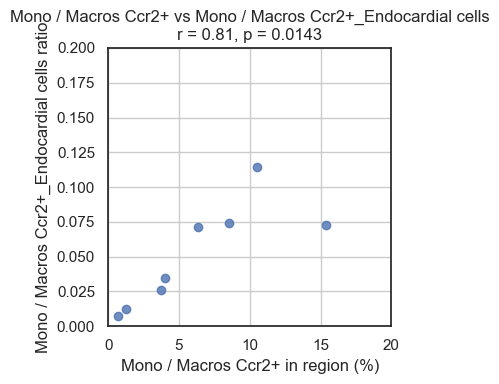

In [26]:
r, p, merged_clean = plot_region_interaction_correlation(
    df1,
    df_pivot,
    target_celltype="Mono / Macros Ccr2+",
    target_interaction="Mono / Macros Ccr2+_Endocardial cells",
    region_column="percent_in_endocardial_region",
    xlim=(0, 20),
    ylim=(0, 0.20),
    #savepath="./../../../../../Paper_figures/202506_dotplots/MI_monocyte_endocard_correlation.svg"
)


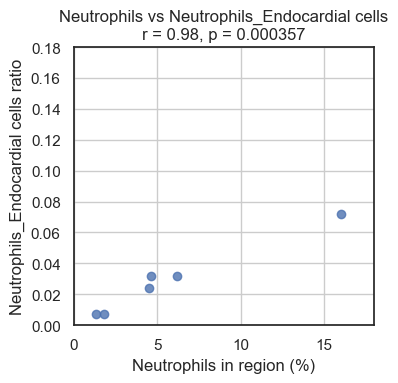

In [27]:
r, p, merged_clean = plot_region_interaction_correlation(
    df1,
    df_pivot,
    target_celltype="Neutrophils",
    target_interaction="Neutrophils_Endocardial cells",
    region_column="percent_in_endocardial_region",
    xlim=(0, 18),
    ylim=(0, 0.18),
    #savepath="./../../../../../Paper_figures/202506_dotplots/MI_monocyte_endocard_correlation.svg"
)

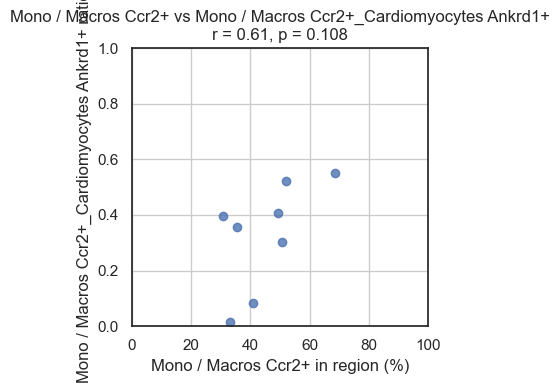

In [28]:
r, p, merged_clean = plot_region_interaction_correlation(
    df2,
    df_pivot,
    target_celltype="Mono / Macros Ccr2+",
    target_interaction="Mono / Macros Ccr2+_Cardiomyocytes Ankrd1+",
    region_column="percent_in_border_zone_or_infarct_core",
    xlim=(0, 100),
    ylim=(0, 1),
    #savepath="./../../../../../Paper_figures/202506_dotplots/MI_monocyte_endocard_correlation.svg"
)

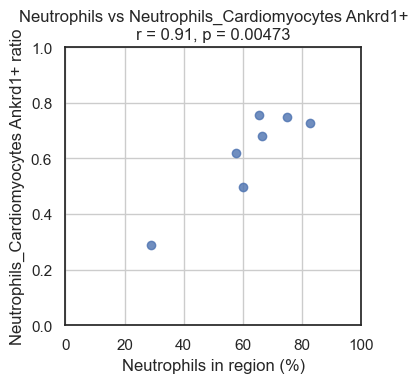

In [29]:
r, p, merged_clean = plot_region_interaction_correlation(
    df2,
    df_pivot,
    target_celltype="Neutrophils",
    target_interaction="Neutrophils_Cardiomyocytes Ankrd1+",
    region_column="percent_in_border_zone_or_infarct_core",
    xlim=(0, 100),
    ylim=(0, 1),
    #savepath="./../../../../../Paper_figures/202506_dotplots/MI_monocyte_endocard_correlation.svg"
)